In [3]:
import numpy as np
import pandas as pd

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report

In [5]:
df=pd.read_csv('/content/bank-additional-full-1 (1).csv')
df

,"age;""job"";""marital"";""education"";""default"";""housing"";""loan"";""contact"";""month"";""day_of_week"";""duration"";""campaign"";""pdays"";""previous"";""poutcome"";""emp.var.rate"";""cons.price.idx"";""cons.conf.idx"";""euribor3m"";""nr.employed"";""y"""
0,"56;""housemaid"";""married"";""basic.4y"";""no"";""no"";..."
1,"57;""services"";""married"";""high.school"";""unknown..."
2,"37;""services"";""married"";""high.school"";""no"";""ye..."
3,"40;""admin."";""married"";""basic.6y"";""no"";""no"";""no..."
4,"56;""services"";""married"";""high.school"";""no"";""no..."
...,...
41194,"74;""retired"";""married"";""professional.course"";""..."
41195,"74;NA;""married"";""professional.course"";""no"";""ye..."
41196,"74;""retired"";""married"";NA;""no"";""yes"";""no"";""cel..."
41197,NA;NA;NA;NA;NA;NA;NA;NA;NA;NA;NA;NA;NA;NA;NA;N...


In [6]:
df=pd.read_csv('/content/bank-additional-full-1 (1).csv',sep=';')
df

,age,job,marital,education,default,housing,loan,contact,month,day_of_week,...,campaign,pdays,previous,poutcome,emp.var.rate,cons.price.idx,cons.conf.idx,euribor3m,nr.employed,y
0,56.0,housemaid,married,basic.4y,no,no,no,telephone,may,mon,...,1.0,999.0,0.0,nonexistent,1.1,93.994,-36.4,4.857,5191.0,no
1,57.0,services,married,high.school,unknown,no,no,telephone,may,mon,...,1.0,999.0,0.0,nonexistent,1.1,93.994,-36.4,4.857,5191.0,no
2,37.0,services,married,high.school,no,yes,no,telephone,may,mon,...,1.0,999.0,0.0,nonexistent,1.1,93.994,-36.4,4.857,5191.0,no
3,40.0,admin.,married,basic.6y,no,no,no,telephone,may,mon,...,1.0,999.0,0.0,nonexistent,1.1,93.994,-36.4,4.857,5191.0,no
4,56.0,services,married,high.school,no,no,yes,telephone,may,mon,...,1.0,999.0,0.0,nonexistent,1.1,93.994,-36.4,4.857,5191.0,no
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
41194,74.0,retired,married,professional.course,no,yes,no,cellular,nov,fri,...,3.0,999.0,1.0,failure,-1.1,94.767,-50.8,1.028,4963.6,no
41195,74.0,NaN,married,professional.course,no,yes,no,cellular,nov,fri,...,3.0,999.0,1.0,failure,-1.1,94.767,-50.8,1.028,4963.6,no
41196,74.0,retired,married,NaN,no,yes,no,cellular,nov,fri,...,3.0,999.0,1.0,failure,-1.1,94.767,-50.8,1.028,4963.6,no
41197,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


In [7]:
df.head()

,age,job,marital,education,default,housing,loan,contact,month,day_of_week,...,campaign,pdays,previous,poutcome,emp.var.rate,cons.price.idx,cons.conf.idx,euribor3m,nr.employed,y
0,56.0,housemaid,married,basic.4y,no,no,no,telephone,may,mon,...,1.0,999.0,0.0,nonexistent,1.1,93.994,-36.4,4.857,5191.0,no
1,57.0,services,married,high.school,unknown,no,no,telephone,may,mon,...,1.0,999.0,0.0,nonexistent,1.1,93.994,-36.4,4.857,5191.0,no
2,37.0,services,married,high.school,no,yes,no,telephone,may,mon,...,1.0,999.0,0.0,nonexistent,1.1,93.994,-36.4,4.857,5191.0,no
3,40.0,admin.,married,basic.6y,no,no,no,telephone,may,mon,...,1.0,999.0,0.0,nonexistent,1.1,93.994,-36.4,4.857,5191.0,no
4,56.0,services,married,high.school,no,no,yes,telephone,may,mon,...,1.0,999.0,0.0,nonexistent,1.1,93.994,-36.4,4.857,5191.0,no


In [8]:
df.tail()

,age,job,marital,education,default,housing,loan,contact,month,day_of_week,...,campaign,pdays,previous,poutcome,emp.var.rate,cons.price.idx,cons.conf.idx,euribor3m,nr.employed,y
41194,74.0,retired,married,professional.course,no,yes,no,cellular,nov,fri,...,3.0,999.0,1.0,failure,-1.1,94.767,-50.8,1.028,4963.6,no
41195,74.0,NaN,married,professional.course,no,yes,no,cellular,nov,fri,...,3.0,999.0,1.0,failure,-1.1,94.767,-50.8,1.028,4963.6,no
41196,74.0,retired,married,NaN,no,yes,no,cellular,nov,fri,...,3.0,999.0,1.0,failure,-1.1,94.767,-50.8,1.028,4963.6,no
41197,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
41198,74.0,retired,married,professional.course,no,yes,NaN,cellular,nov,fri,...,3.0,999.0,1.0,failure,-1.1,NaN,-50.8,1.028,4963.6,no


In [9]:
df.describe()

,age,duration,campaign,pdays,previous,emp.var.rate,cons.price.idx,cons.conf.idx,euribor3m,nr.employed
count,41195.000000,41196.000000,41196.000000,41196.000000,41196.000000,41196.000000,41195.000000,41196.000000,41196.000000,41196.000000
mean,40.030319,258.281265,2.567676,962.482547,0.173124,0.081656,93.575867,-40.504600,3.620787,5166.996405
std,10.431818,259.254211,2.769751,186.893451,0.494987,1.570894,0.578999,4.629972,1.734655,72.300104
min,17.000000,0.000000,1.000000,0.000000,0.000000,-3.400000,92.201000,-50.800000,0.634000,4963.600000
25%,32.000000,102.000000,1.000000,999.000000,0.000000,-1.800000,93.075000,-42.700000,1.344000,5099.100000
50%,38.000000,180.000000,2.000000,999.000000,0.000000,1.100000,93.749000,-41.800000,4.857000,5191.000000
75%,47.000000,319.000000,3.000000,999.000000,0.000000,1.400000,93.994000,-36.400000,4.961000,5228.100000
max,98.000000,4918.000000,56.000000,999.000000,7.000000,1.400000,94.767000,-26.900000,5.045000,5228.100000


In [10]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 41199 entries, 0 to 41198
Data columns (total 21 columns):
 #   Column          Non-Null Count  Dtype  
---  ------          --------------  -----  
 0   age             41195 non-null  float64
 1   job             41194 non-null  object 
 2   marital         41194 non-null  object 
 3   education       41194 non-null  object 
 4   default         41195 non-null  object 
 5   housing         41196 non-null  object 
 6   loan            41195 non-null  object 
 7   contact         41195 non-null  object 
 8   month           41196 non-null  object 
 9   day_of_week     41196 non-null  object 
 10  duration        41196 non-null  float64
 11  campaign        41196 non-null  float64
 12  pdays           41196 non-null  float64
 13  previous        41196 non-null  float64
 14  poutcome        41194 non-null  object 
 15  emp.var.rate    41196 non-null  float64
 16  cons.price.idx  41195 non-null  float64
 17  cons.conf.idx   41196 non-null 

In [11]:
df.shape

(41199, 21)

In [12]:
df.columns

Index(['age', 'job', 'marital', 'education', 'default', 'housing', 'loan',
       'contact', 'month', 'day_of_week', 'duration', 'campaign', 'pdays',
       'previous', 'poutcome', 'emp.var.rate', 'cons.price.idx',
       'cons.conf.idx', 'euribor3m', 'nr.employed', 'y'],
      dtype='object')

age: Age of the customer/client

job: Type of job

married: Marital Status of customer

education: Education level.

default: The person has a history of default credit or loan (Bad credit).

housing: Has housing loan

loan: Has personal loan

contact Contact communication type

month: Last contact month

day_of_week: Last contact day of the week (Mon,Tue..)

duration: Last contact duration in seconds.

campaign: Number of contacts perfomed during this campagin.

pdays: Days since the client was last contacted (999 means never contacted before.)

previous: Number of contacts before this campaign.

poutcome: Outcome of the previous marketing campaign.

emp.var.rate: Employement variation rate (Employement rate)

cons.price.idx: Consumer price index, an indicator that measures average price changes for goods and services bought by households.

cons.conf.idx: Consumer confidence index, it measures how confident/satisfied/optimistic people feel about the economy.

euribor3m: Euribor 3month rate. It is the interest rate at which European banks lend money to each other for 3 months.

nr.employed: Number of employed people.

y: Has the client subscribed/took the fixed deposit/term deposit.



In [13]:
df.isnull().sum()

,0
age,4
job,5
marital,5
education,5
default,4
housing,3
loan,4
contact,4
month,3
day_of_week,3


In [15]:
for i in df.columns:
  if(df[i].dtype == "object"):
    df[i] = df[i].fillna(df[i].mode()[0])
  else:
    df[i] = df[i].fillna(df[i].mean())

In [16]:
df.isnull().sum()

,0
age,0
job,0
marital,0
education,0
default,0
housing,0
loan,0
contact,0
month,0
day_of_week,0


In [17]:
df.duplicated().sum()

np.int64(16)

In [18]:
df.drop_duplicates(inplace=True)

⚡**Visualization**

  **Box plot is used to check the outliers in Data**

In [19]:
import matplotlib.pyplot as plt


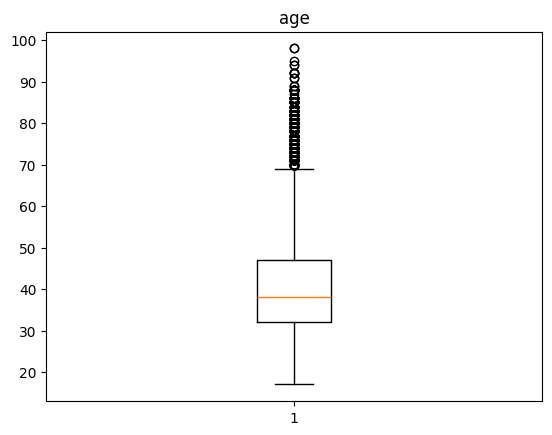

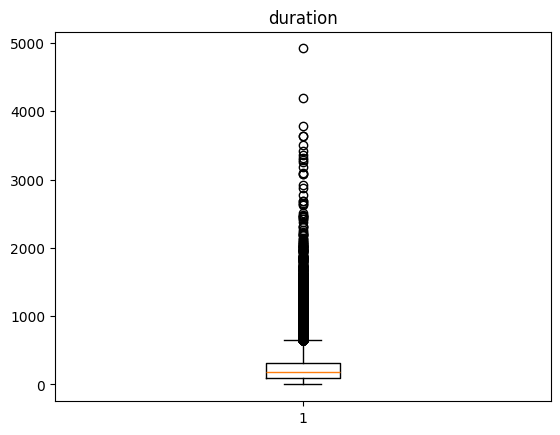

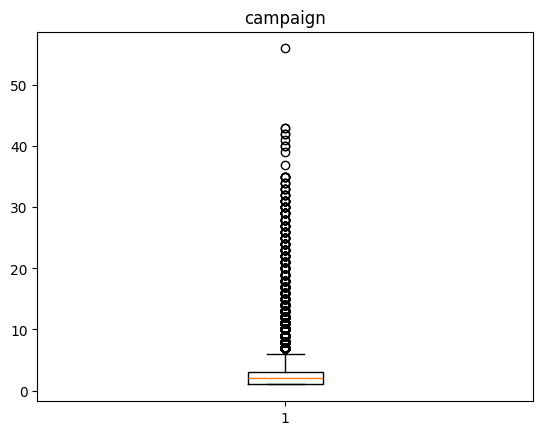

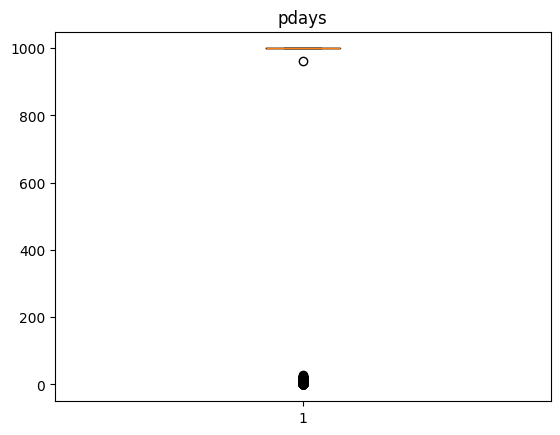

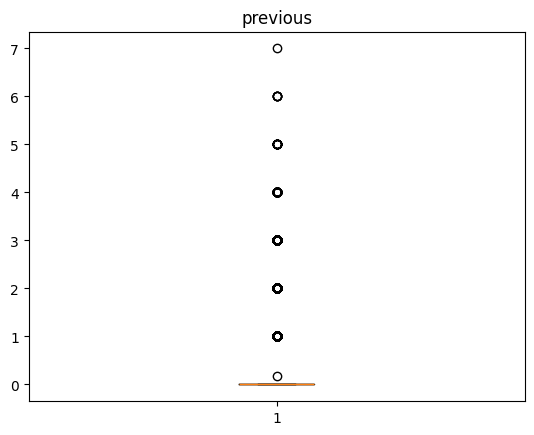

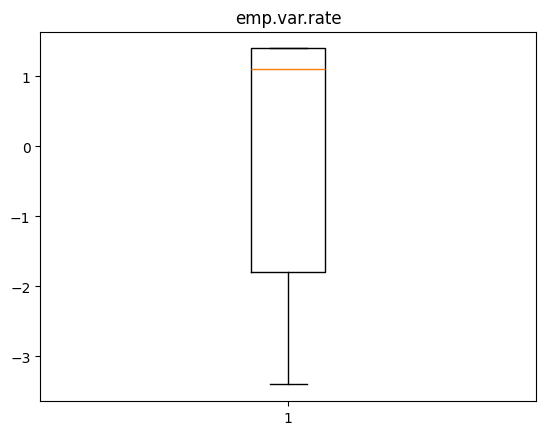

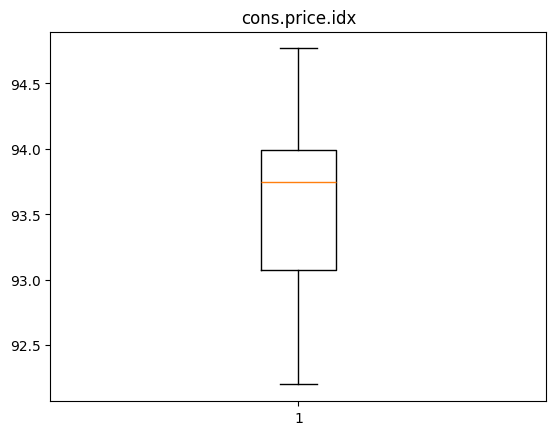

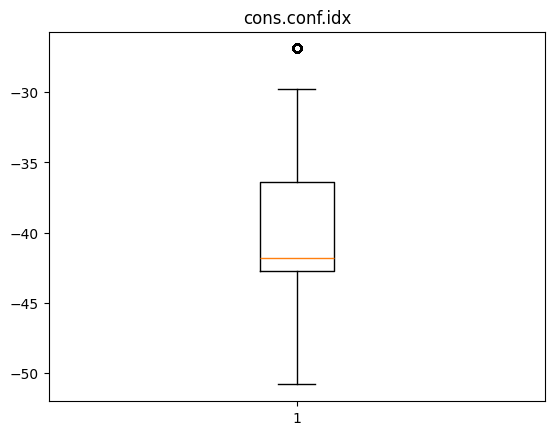

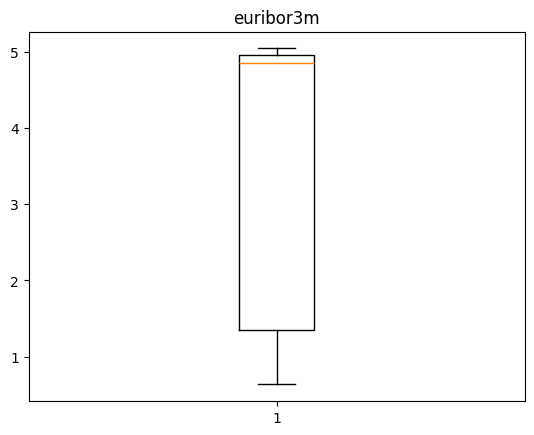

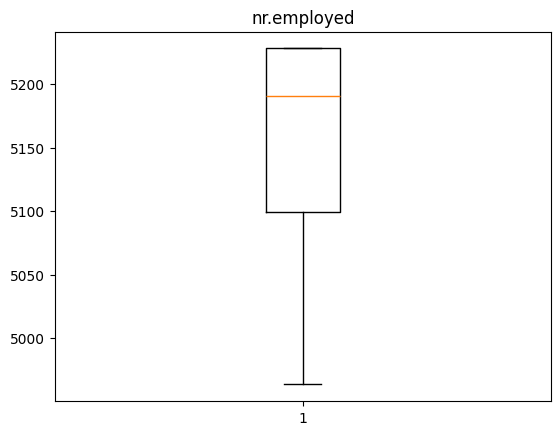

In [21]:
for i in df.columns:
  if(df[i].dtype != "object"):
    plt.boxplot(df[i])
    plt.title(i)
    plt.show()


In [22]:
from sklearn.preprocessing import LabelEncoder

In [23]:
le=LabelEncoder()

In [24]:
for i in df.columns:
  if(df[i].dtype == "object"):
    df[i] = le.fit_transform(df[i])

In [25]:
df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 41183 entries, 0 to 41198
Data columns (total 21 columns):
 #   Column          Non-Null Count  Dtype  
---  ------          --------------  -----  
 0   age             41183 non-null  float64
 1   job             41183 non-null  int64  
 2   marital         41183 non-null  int64  
 3   education       41183 non-null  int64  
 4   default         41183 non-null  int64  
 5   housing         41183 non-null  int64  
 6   loan            41183 non-null  int64  
 7   contact         41183 non-null  int64  
 8   month           41183 non-null  int64  
 9   day_of_week     41183 non-null  int64  
 10  duration        41183 non-null  float64
 11  campaign        41183 non-null  float64
 12  pdays           41183 non-null  float64
 13  previous        41183 non-null  float64
 14  poutcome        41183 non-null  int64  
 15  emp.var.rate    41183 non-null  float64
 16  cons.price.idx  41183 non-null  float64
 17  cons.conf.idx   41183 non-null  floa

1. Split the data into x,y

2. Split the data into train and test

3. Train the model

4. Test the model

5. Evaluate the Model

1. Split the data into x,y


In [26]:
x = df.drop(columns=["y"])
x

,age,job,marital,education,default,housing,loan,contact,month,day_of_week,duration,campaign,pdays,previous,poutcome,emp.var.rate,cons.price.idx,cons.conf.idx,euribor3m,nr.employed
0,56.0,3,1,0,0,0,0,1,6,1,261.0,1.0,999.0,0.0,1,1.1,93.994000,-36.4,4.857,5191.0
1,57.0,7,1,3,1,0,0,1,6,1,149.0,1.0,999.0,0.0,1,1.1,93.994000,-36.4,4.857,5191.0
2,37.0,7,1,3,0,2,0,1,6,1,226.0,1.0,999.0,0.0,1,1.1,93.994000,-36.4,4.857,5191.0
3,40.0,0,1,1,0,0,0,1,6,1,151.0,1.0,999.0,0.0,1,1.1,93.994000,-36.4,4.857,5191.0
4,56.0,7,1,3,0,0,2,1,6,1,307.0,1.0,999.0,0.0,1,1.1,93.994000,-36.4,4.857,5191.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
41190,74.0,0,1,6,0,2,0,0,7,0,239.0,3.0,999.0,1.0,1,-1.1,94.767000,-50.8,1.028,4963.6
41193,94.0,5,1,5,0,2,0,0,7,0,239.0,3.0,999.0,1.0,0,-1.1,94.767000,-50.8,1.028,4963.6
41195,74.0,0,1,5,0,2,0,0,7,0,239.0,3.0,999.0,1.0,0,-1.1,94.767000,-50.8,1.028,4963.6
41196,74.0,5,1,6,0,2,0,0,7,0,239.0,3.0,999.0,1.0,0,-1.1,94.767000,-50.8,1.028,4963.6


In [27]:
y = df["y"]
y

,y
0,0
1,0
2,0
3,0
4,0
...,...
41190,0
41193,0
41195,0
41196,0


2.Split the data into train and test

In [ ]:
from sklearn.model_selection import train_test_split

In [28]:
x_train,x_test,y_train,y_test=train_test_split(x,y,test_size=0.2,random_state=42)

In [29]:
x_train.shape

(32946, 20)

In [30]:
y_train.shape

(32946,)

In [31]:
x_test.shape

(8237, 20)

In [32]:
y_test.shape

(8237,)

In [33]:
from sklearn.linear_model import LogisticRegression

In [38]:
model = LogisticRegression()

In [39]:
model.fit(x_train, y_train)

/usr/local/lib/python3.12/dist-packages/sklearn/linear_model/_logistic.py:465: ConvergenceWarning: lbfgs failed to converge (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT.

Increase the number of iterations (max_iter) or scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(


LogisticRegression()

In [40]:
y_pred = model.predict(x_test)

In [41]:
y_pred

array([0, 1, 0, ..., 0, 0, 0])

In [42]:
y_test

,y
28879,0
24613,1
5383,0
31060,0
32773,0
...,...
23052,0
25077,0
25952,1
1872,0


**Evalution**

In [44]:
from sklearn.metrics import accuracy_score

In [45]:
accuracy_score(y_test, y_pred)

0.9080976083525556

In [46]:
from sklearn.metrics import *

In [47]:
print(classification_report(y_test, y_pred))

              precision    recall  f1-score   support

           0       0.93      0.97      0.95      7331
           1       0.64      0.39      0.48       906

    accuracy                           0.91      8237
   macro avg       0.78      0.68      0.72      8237
weighted avg       0.90      0.91      0.90      8237



In [48]:
confusion_matrix(y_test, y_pred)

array([[7130,  201],
       [ 556,  350]])

In [50]:
from sklearn.metrics import accuracy_score
from sklearn.metrics import confusion_matrix
from sklearn.metrics import classification_report

In [53]:
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report

y_pred = model.predict(x_test)

print("Accuracy:", accuracy_score(y_test, y_pred))

print("Confusion Matrix:")
print(confusion_matrix(y_test, y_pred))

print("Report:")
print(classification_report(y_test, y_pred))

Accuracy: 0.9080976083525556
Confusion Matrix:
[[7130  201]
 [ 556  350]]
Report:
              precision    recall  f1-score   support

           0       0.93      0.97      0.95      7331
           1       0.64      0.39      0.48       906

    accuracy                           0.91      8237
   macro avg       0.78      0.68      0.72      8237
weighted avg       0.90      0.91      0.90      8237



In [54]:
from sklearn.preprocessing import StandardScaler

In [55]:
x

,age,job,marital,education,default,housing,loan,contact,month,day_of_week,duration,campaign,pdays,previous,poutcome,emp.var.rate,cons.price.idx,cons.conf.idx,euribor3m,nr.employed
0,56.0,3,1,0,0,0,0,1,6,1,261.0,1.0,999.0,0.0,1,1.1,93.994000,-36.4,4.857,5191.0
1,57.0,7,1,3,1,0,0,1,6,1,149.0,1.0,999.0,0.0,1,1.1,93.994000,-36.4,4.857,5191.0
2,37.0,7,1,3,0,2,0,1,6,1,226.0,1.0,999.0,0.0,1,1.1,93.994000,-36.4,4.857,5191.0
3,40.0,0,1,1,0,0,0,1,6,1,151.0,1.0,999.0,0.0,1,1.1,93.994000,-36.4,4.857,5191.0
4,56.0,7,1,3,0,0,2,1,6,1,307.0,1.0,999.0,0.0,1,1.1,93.994000,-36.4,4.857,5191.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
41190,74.0,0,1,6,0,2,0,0,7,0,239.0,3.0,999.0,1.0,1,-1.1,94.767000,-50.8,1.028,4963.6
41193,94.0,5,1,5,0,2,0,0,7,0,239.0,3.0,999.0,1.0,0,-1.1,94.767000,-50.8,1.028,4963.6
41195,74.0,0,1,5,0,2,0,0,7,0,239.0,3.0,999.0,1.0,0,-1.1,94.767000,-50.8,1.028,4963.6
41196,74.0,5,1,6,0,2,0,0,7,0,239.0,3.0,999.0,1.0,0,-1.1,94.767000,-50.8,1.028,4963.6


In [56]:
scaler = StandardScaler()

In [57]:
x_scaled = scaler.fit_transform(x)

In [58]:
x_scaled

array([[ 1.5315418 , -0.20144178, -0.2836773 , ...,  0.88664797,
         0.71262501,  0.33194188],
       [ 1.62743344,  0.91143995, -0.2836773 , ...,  0.88664797,
         0.71262501,  0.33194188],
       [-0.29039932,  0.91143995, -0.2836773 , ...,  0.88664797,
         0.71262501,  0.33194188],
       ...,
       [ 3.25759128, -1.03610308, -0.2836773 , ..., -2.22412197,
        -1.49486276, -2.81389296],
       [ 3.25759128,  0.35499908, -0.2836773 , ..., -2.22412197,
        -1.49486276, -2.81389296],
       [ 3.25759128,  0.35499908, -0.2836773 , ..., -2.22412197,
        -1.49486276, -2.81389296]])

In [59]:
from sklearn.linear_model import LogisticRegression
from sklearn.feature_selection import RFE

In [60]:
model = LogisticRegression()

In [61]:
rfe = RFE(model)

In [62]:
rfe.fit(x,y)

/usr/local/lib/python3.12/dist-packages/sklearn/linear_model/_logistic.py:465: ConvergenceWarning: lbfgs failed to converge (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT.

Increase the number of iterations (max_iter) or scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(
/usr/local/lib/python3.12/dist-packages/sklearn/linear_model/_logistic.py:465: ConvergenceWarning: lbfgs failed to converge (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT.

Increase the number of iterations (max_iter) or scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _c

RFE(estimator=LogisticRegression())

In [63]:
rfe.support_

array([False, False,  True, False,  True, False, False,  True,  True,
        True, False,  True, False,  True,  True, False, False,  True,
        True, False])

In [64]:
x.columns

Index(['age', 'job', 'marital', 'education', 'default', 'housing', 'loan',
       'contact', 'month', 'day_of_week', 'duration', 'campaign', 'pdays',
       'previous', 'poutcome', 'emp.var.rate', 'cons.price.idx',
       'cons.conf.idx', 'euribor3m', 'nr.employed'],
      dtype='object')

In [65]:
len(rfe.support_)

20

In [67]:
new_cols = []
for i in range(len(rfe.support_)):
  if (rfe.support_[i]==True):
    new_cols.append(x.columns[i])

In [68]:
new_cols

['marital',
 'default',
 'contact',
 'month',
 'day_of_week',
 'campaign',
 'previous',
 'poutcome',
 'cons.conf.idx',
 'euribor3m']

In [69]:
x

,age,job,marital,education,default,housing,loan,contact,month,day_of_week,duration,campaign,pdays,previous,poutcome,emp.var.rate,cons.price.idx,cons.conf.idx,euribor3m,nr.employed
0,56.0,3,1,0,0,0,0,1,6,1,261.0,1.0,999.0,0.0,1,1.1,93.994000,-36.4,4.857,5191.0
1,57.0,7,1,3,1,0,0,1,6,1,149.0,1.0,999.0,0.0,1,1.1,93.994000,-36.4,4.857,5191.0
2,37.0,7,1,3,0,2,0,1,6,1,226.0,1.0,999.0,0.0,1,1.1,93.994000,-36.4,4.857,5191.0
3,40.0,0,1,1,0,0,0,1,6,1,151.0,1.0,999.0,0.0,1,1.1,93.994000,-36.4,4.857,5191.0
4,56.0,7,1,3,0,0,2,1,6,1,307.0,1.0,999.0,0.0,1,1.1,93.994000,-36.4,4.857,5191.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
41190,74.0,0,1,6,0,2,0,0,7,0,239.0,3.0,999.0,1.0,1,-1.1,94.767000,-50.8,1.028,4963.6
41193,94.0,5,1,5,0,2,0,0,7,0,239.0,3.0,999.0,1.0,0,-1.1,94.767000,-50.8,1.028,4963.6
41195,74.0,0,1,5,0,2,0,0,7,0,239.0,3.0,999.0,1.0,0,-1.1,94.767000,-50.8,1.028,4963.6
41196,74.0,5,1,6,0,2,0,0,7,0,239.0,3.0,999.0,1.0,0,-1.1,94.767000,-50.8,1.028,4963.6


In [70]:
x = x.loc[:,new_cols]

In [71]:
x

,marital,default,contact,month,day_of_week,campaign,previous,poutcome,cons.conf.idx,euribor3m
0,1,0,1,6,1,1.0,0.0,1,-36.4,4.857
1,1,1,1,6,1,1.0,0.0,1,-36.4,4.857
2,1,0,1,6,1,1.0,0.0,1,-36.4,4.857
3,1,0,1,6,1,1.0,0.0,1,-36.4,4.857
4,1,0,1,6,1,1.0,0.0,1,-36.4,4.857
...,...,...,...,...,...,...,...,...,...,...
41190,1,0,0,7,0,3.0,1.0,1,-50.8,1.028
41193,1,0,0,7,0,3.0,1.0,0,-50.8,1.028
41195,1,0,0,7,0,3.0,1.0,0,-50.8,1.028
41196,1,0,0,7,0,3.0,1.0,0,-50.8,1.028


In [72]:
x_train, x_test, y_train, y_test = train_test_split(x,y,test_size=0.2, random_state=42)

In [73]:
model = LogisticRegression()

In [74]:
model.fit(x_train, y_train)

LogisticRegression()

In [75]:
y_pred = model.predict(x_test)

In [76]:
y_pred

array([0, 0, 0, ..., 0, 0, 0])

In [77]:
y_test


,y
28879,0
24613,1
5383,0
31060,0
32773,0
...,...
23052,0
25077,0
25952,1
1872,0


In [78]:
accuracy_score(y_test, y_pred)

0.9014204200558456

In [80]:
print(classification_report(y_test, y_pred))

              precision    recall  f1-score   support

           0       0.91      0.99      0.95      7331
           1       0.69      0.19      0.29       906

    accuracy                           0.90      8237
   macro avg       0.80      0.59      0.62      8237
weighted avg       0.88      0.90      0.88      8237



In [83]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()

x_train_scaled = scaler.fit_transform(x_train)
x_test_scaled = scaler.transform(x_test)

In [84]:
x_train_scaled

array([[ 1.36163509, -0.51323723,  1.31702762, ...,  0.19196599,
        -0.47171902,  0.77094803],
       [ 1.36163509, -0.51323723,  1.31702762, ...,  0.19196599,
        -0.27759352,  0.71622066],
       [-0.28070171, -0.51323723, -0.75928552, ...,  0.19196599,
        -0.06189853, -1.3449848 ],
       ...,
       [-0.28070171, -0.51323723, -0.75928552, ..., -2.57587269,
         2.93626192, -1.65145805],
       [-0.28070171, -0.51323723,  1.31702762, ...,  0.19196599,
         0.88715945,  0.71161204],
       [ 1.36163509,  1.94627023, -0.75928552, ...,  0.19196599,
        -0.47171902,  0.77152411]])

In [85]:
x_test_scaled

array([[-0.28070171,  1.94627023, -0.75928552, ...,  0.19196599,
        -1.420777  , -1.27355118],
       [-0.28070171, -0.51323723, -0.75928552, ...,  2.95980466,
        -0.32073252,  0.32852047],
       [-0.28070171, -0.51323723,  1.31702762, ...,  0.19196599,
         0.88715945,  0.71218812],
       ...,
       [ 1.36163509, -0.51323723, -0.75928552, ...,  0.19196599,
        -0.32073252,  0.28761897],
       [-0.28070171, -0.51323723,  1.31702762, ...,  0.19196599,
         0.88715945,  0.71103596],
       [ 1.36163509, -0.51323723,  1.31702762, ..., -2.57587269,
        -0.32073252,  0.28761897]])